In [10]:
import re
from pathlib import Path
import geopandas as gpd
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Find the PBF file
candidate_paths = [
    Path("limburg-260312.osm.pbf"),
    Path("../limburg-260312.osm.pbf"),
]
pbf_path = next((p for p in candidate_paths if p.exists()), None)
if pbf_path is None:
    raise FileNotFoundError("Could not find limburg-260312.osm.pbf in current or parent folder.")

In [12]:
# Load points and roads for Heerlen
points = gpd.read_file(pbf_path, layer="points")
points = points.to_crs(epsg=3857)

heerlen_boundary = ox.geocode_to_gdf("Heerlen, Limburg, Netherlands").to_crs(points.crs)
points_heerlen = gpd.clip(points, heerlen_boundary.geometry.iloc[0])

roads = gpd.read_file(pbf_path, layer="lines")
roads = roads.to_crs(epsg=3857)
roads_heerlen = gpd.clip(roads, heerlen_boundary.geometry.iloc[0])

points_with_addr = points_heerlen[points_heerlen['other_tags'].notna() & points_heerlen['other_tags'].str.contains('addr:', na=False)].copy()

In [13]:
# Extract address information from points' other_tags and sample 100 random addresses within Heerlen

# Sample 100 random points from points_heerlen
sample_points = points_with_addr.sample(n=min(100, len(points_with_addr)), random_state=42).copy()

# Extract address components from other_tags
def extract_address_info(other_tags):
    if pd.isna(other_tags):
        return {}
    
    info = {}
    # Extract common address fields
    patterns = {
        'street': r'"addr:street"=>"([^"]+)"',
        'housenumber': r'"addr:housenumber"=>"([^"]+)"',
        'postcode': r'"addr:postcode"=>"([^"]+)"',
        'city': r'"addr:city"=>"([^"]+)"',
    }
    
    for key, pattern in patterns.items():
        match = re.search(pattern, other_tags)
        info[key] = match.group(1) if match else None
    
    return info

# Apply extraction
address_data = sample_points['other_tags'].apply(extract_address_info)
address_df = pd.DataFrame(list(address_data))

# Combine with geometry
sample_points_with_addr = pd.concat([
    sample_points[['geometry']].reset_index(drop=True),
    address_df
], axis=1)

# Create full address string
sample_points_with_addr['full_address'] = (
    sample_points_with_addr['street'].fillna('') + ' ' +
    sample_points_with_addr['housenumber'].fillna('') + ', ' +
    sample_points_with_addr['postcode'].fillna('') + ' ' +
    sample_points_with_addr['city'].fillna('')
).str.strip()


In [18]:
# Add coordinates as WKT LINESTRING text for each address
# Note: an address is a point, so we repeat the same coordinate twice to keep valid LINESTRING WKT.
def get_coordinates(address):
    """Geocode address and return WKT LINESTRING (lon lat, lon lat), or None if geocoding fails."""
    if pd.isna(address) or not address:
        return None

    try:
        lat, lon = ox.geocode(address)
        return f"{lat} {lon}"
    except Exception:
        return None

# Apply geocoding to full_address column
output_addresses["coordinates"] = output_addresses["full_address"].apply(get_coordinates)

# Save updated CSV with coordinates
output_addresses.to_csv("../output/heerlen_addresses.csv", index=False)

print("Updated CSV with coordinates saved to ../output/heerlen_addresses.csv")
print("\nSample addresses with coordinates:")
print(output_addresses[["full_address", "coordinates"]].head(10))

# Check for any missing coordinates
missing_coords = output_addresses["coordinates"].isna().sum()
if missing_coords > 0:
    print(f"\nWarning: {missing_coords} addresses failed to geocode")
else:
    print(f"\nAll {len(output_addresses)} addresses successfully geocoded!")

Updated CSV with coordinates saved to ../output/heerlen_addresses.csv

Sample addresses with coordinates:
                              full_address           coordinates
0            Tempsplein 13, 6411ES Heerlen  50.8849685 5.9788965
1        Gasthuisstraat 47, 6416AM Heerlen  50.8881082 5.9860769
2           Kampstraat 124, 6413EG Heerlen  50.9193216 5.9595728
3          Ammonieterf 293, 6413KT Heerlen  50.9100525 5.9496824
4         Donderdagstraat 9-GB38,  Heerlen  50.8853564 5.9958273
5               Putgraaf 5, 6411GT Heerlen  50.8865314 5.9815941
6          Gravenstraat 28, 6413ES Heerlen   50.915118 5.9580691
7       Frans Halsstraat 6, 6415TH Heerlen  50.9003376 5.9904336
8          K.L.M.-straat 3, 6417AW Heerlen   50.874236 5.9876054
9  Titus Brandsmastraat 25, 6414BK Heerlen  50.9142258 5.9689164

All 100 addresses successfully geocoded!


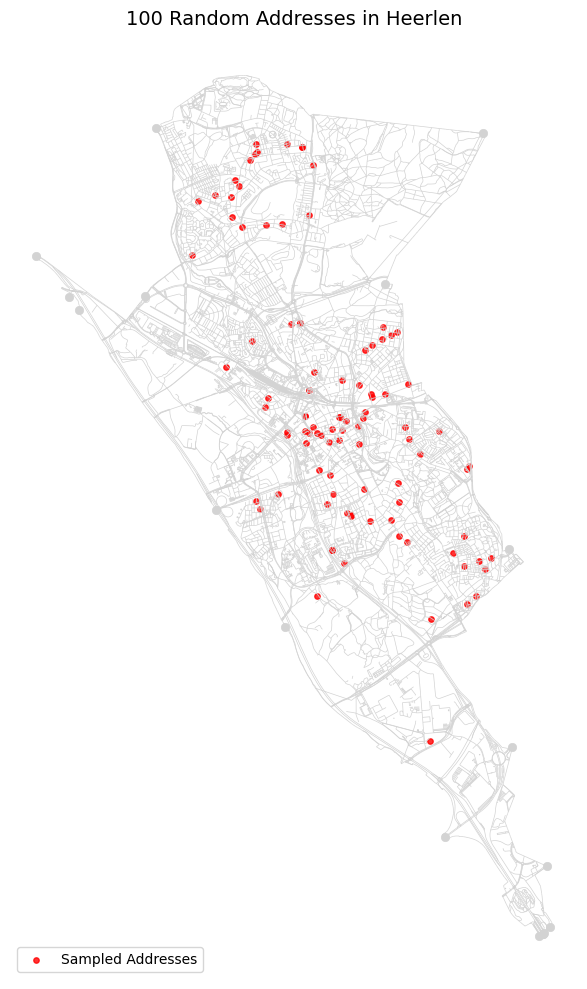

Saved 100 addresses to ../output/heerlen_addresses.csv
                 street housenumber postcode     city  \
0            Tempsplein          13   6411ES  Heerlen   
1        Gasthuisstraat          47   6416AM  Heerlen   
2            Kampstraat         124   6413EG  Heerlen   
3           Ammonieterf         293   6413KT  Heerlen   
4       Donderdagstraat      9-GB38      NaN  Heerlen   
5              Putgraaf           5   6411GT  Heerlen   
6          Gravenstraat          28   6413ES  Heerlen   
7      Frans Halsstraat           6   6415TH  Heerlen   
8         K.L.M.-straat           3   6417AW  Heerlen   
9  Titus Brandsmastraat          25   6414BK  Heerlen   

                              full_address           coordinates  
0            Tempsplein 13, 6411ES Heerlen  50.8849685 5.9788965  
1        Gasthuisstraat 47, 6416AM Heerlen  50.8881082 5.9860769  
2           Kampstraat 124, 6413EG Heerlen  50.9193216 5.9595728  
3          Ammonieterf 293, 6413KT Heerlen  50.91

In [19]:
# Plot on roads
fig, ax = plt.subplots(figsize=(10, 10))
roads_heerlen.plot(ax=ax, linewidth=0.5, color="lightgray")
sample_points_with_addr.plot(ax=ax, color="red", markersize=15, alpha=0.8, label="Sampled Addresses")

ax.set_title(f"100 Random Addresses in Heerlen", fontsize=14)
ax.set_axis_off()
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Saved {len(output_addresses)} addresses to ../output/heerlen_addresses.csv")
print(output_addresses.head(10))